## Progress Report

## 1. Overview

This progress report documents our work since the project proposal. We have:
1. Finalized data cleaning and preparation
2. Conducted EDA
3. Built baseline models (Linear/Logistic Regression) and Random Forest models
4. Compared listing only vs. listing and demographic features

Dataset consists of 280,286 Airbnb listings across 34 US cities, merged with Census ACS 2023 tract-level demographics.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error, accuracy_score, classification_report, roc_auc_score)
import warnings
warnings.filterwarnings("ignore")

## 2. Data Loading and Preparation

In [ ]:
# the full cleaned dataset is split into two parts because of file size
df1 = pd.read_csv("data/airbnb_cleaned_part1.csv", index_col=0)
df2 = pd.read_csv("data/airbnb_cleaned_part2.csv", index_col=0)
df = pd.concat([df1, df2], ignore_index=True)

In [ ]:
df["median_age"] = df["median_age"].where(df["median_age"] > 0, other=np.nan)

# host_response_rate and host_acceptance_rate are stored as strings with %
for col in ["host_response_rate", "host_acceptance_rate"]:
    df[col] = df[col].astype(str).str.rstrip("%").replace("nan", np.nan)
    df[col] = pd.to_numeric(df[col], errors="coerce") / 100.0

# make sure boolean columns are numeric
for col in ["host_identity_verified", "host_has_profile_pic", "instant_bookable", "host_is_superhost"]:
    df[col] = df[col].map({True: 1, False: 0, "True": 1, "False": 0,
                           "t": 1, "f": 0, 1: 1, 0: 0})
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

### Missing Values
Price and estimated revenue are missing for about 43% of listings. Review scores are missing for ~21%.
Demographic variables from Census are nearly complete.

In [ ]:
key_cols = ["price", "estimated_occupancy_l365d", "estimated_revenue_l365d", "review_scores_rating", "median_household_income", "poverty_rate"]

missing = df[key_cols].isnull().sum()
missing_pct = (missing / len(df) * 100)
pd.DataFrame({"count": missing, "pct": missing_pct}).sort_values("pct", ascending=False)

## 3. Exploratory Data Analysis

### Distribution of Target Variables

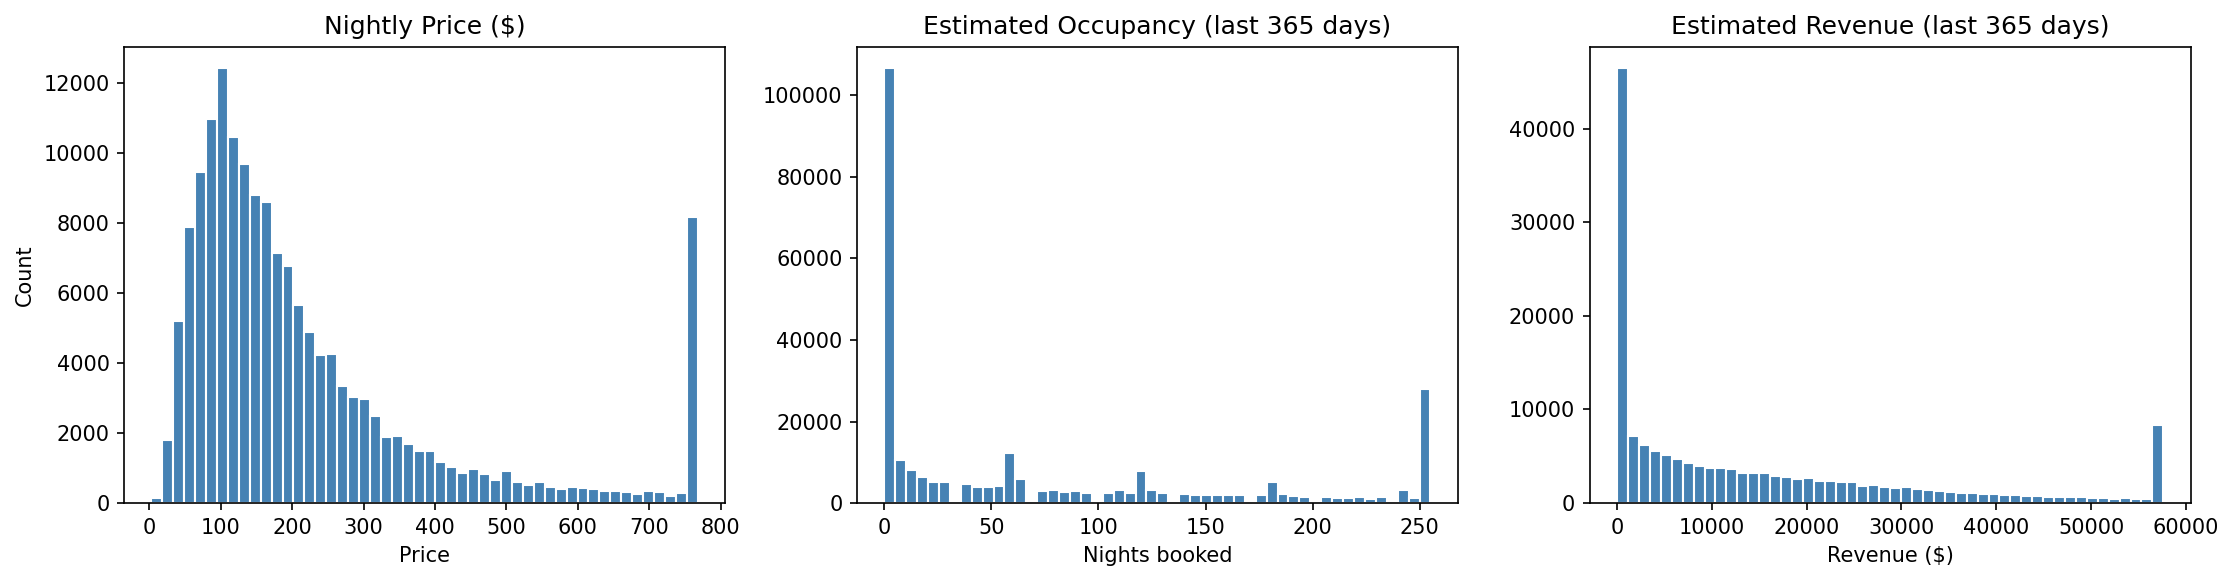

In [ ]:
df_price = df.dropna(subset=["price"])
df_price = df_price[df_price["price"] > 0]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df_price["price"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Nightly Price ($)")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")

axes[1].hist(df["estimated_occupancy_l365d"], bins=50, color="steelblue", edgecolor="white")
axes[1].set_title("Estimated Occupancy (last 365 days)")
axes[1].set_xlabel("Nights booked")

df_rev = df.dropna(subset=["estimated_revenue_l365d"])
axes[2].hist(df_rev["estimated_revenue_l365d"], bins=50, color="steelblue", edgecolor="white")
axes[2].set_title("Estimated Revenue (last 365 days)")
axes[2].set_xlabel("Revenue ($)")

plt.tight_layout()
plt.show()

Price is right-skewed with most listings between $50-$300/night. Occupancy shows a large cluster at 0 
(inactive or new listings) and a spread across the range. Revenue follows a similar right-skewed pattern.

### Correlation Matrix

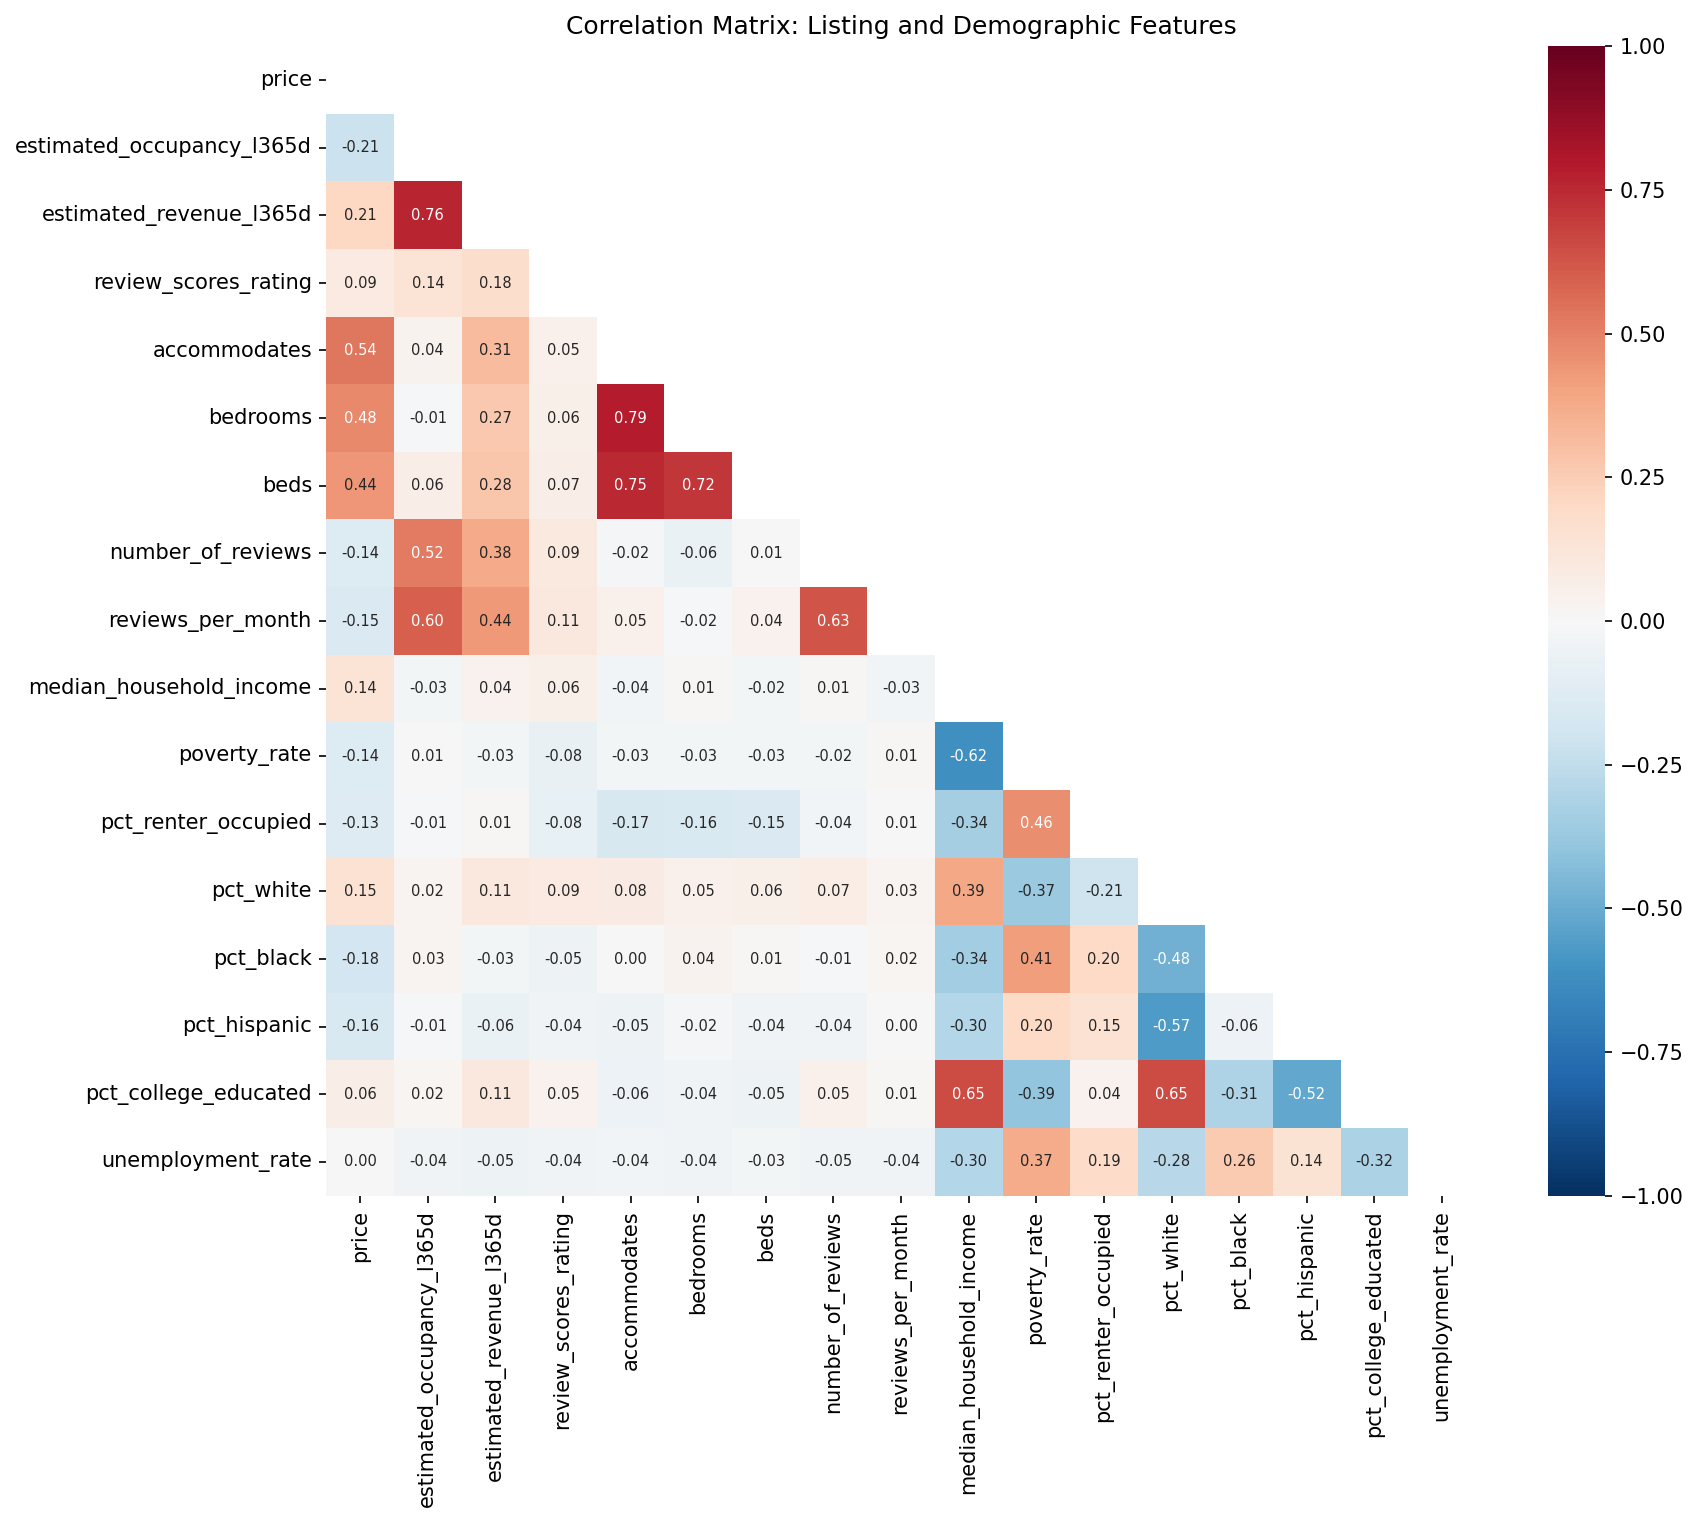

In [ ]:
corr_cols = ["price", "estimated_occupancy_l365d", "estimated_revenue_l365d",
             "review_scores_rating", "accommodates", "bedrooms", "beds",
             "number_of_reviews", "reviews_per_month",
             "median_household_income", "poverty_rate", "pct_renter_occupied",
             "pct_white", "pct_black", "pct_hispanic", "pct_college_educated",
             "unemployment_rate"]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, ax=ax, square=True,
            annot_kws={"size": 7})
ax.set_title("Correlation Matrix: Listing and Demographic Features")
plt.tight_layout()
plt.show()

Key observations from the correlation matrix:
- Price is positively correlated with accommodates (0.52), bedrooms (0.44), and median household income (0.18)
- Price is negatively correlated with poverty rate (-0.14) and pct_black (-0.14)
- Occupancy has moderate correlation with reviews per month (0.48) and number of reviews (0.29)
- Demographic variables show expected intercorrelations (e.g., income vs poverty rate: -0.53)

### Price and Occupancy by Room Type

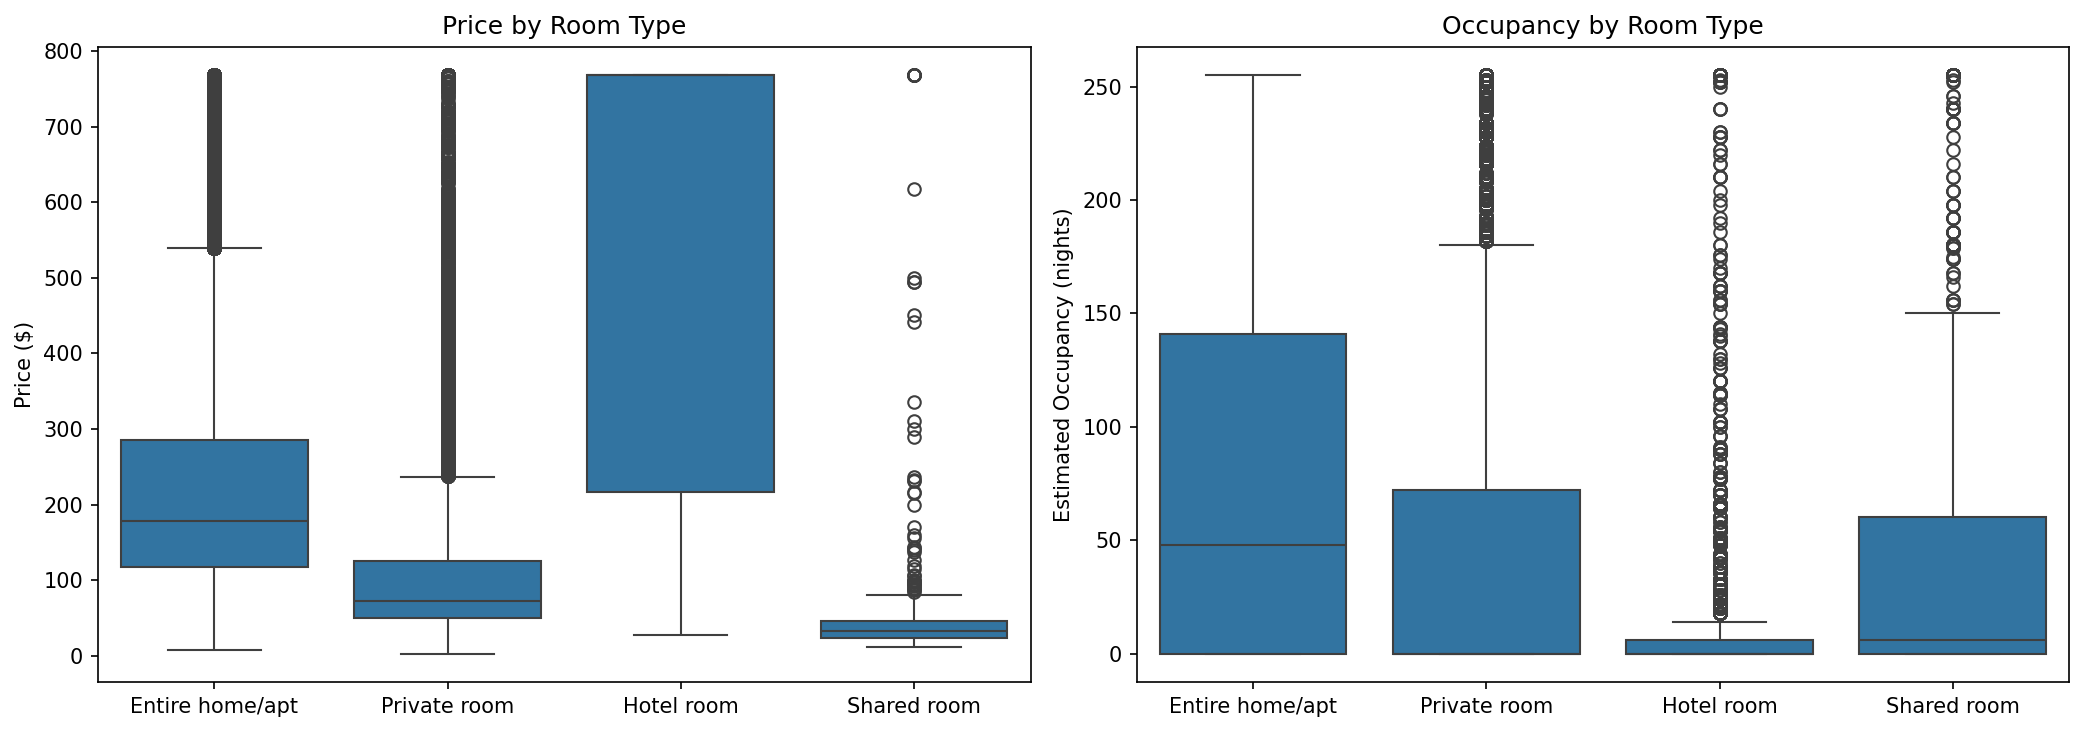

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

room_order = df_price["room_type"].value_counts().index.tolist()
sns.boxplot(data=df_price, x="room_type", y="price", order=room_order, ax=axes[0])
axes[0].set_title("Price by Room Type")
axes[0].set_xlabel("")
axes[0].set_ylabel("Price ($)")

sns.boxplot(data=df, x="room_type", y="estimated_occupancy_l365d", order=room_order, ax=axes[1])
axes[1].set_title("Occupancy by Room Type")
axes[1].set_xlabel("")
axes[1].set_ylabel("Estimated Occupancy (nights)")

plt.tight_layout()
plt.show()

### Demographic Features vs Price

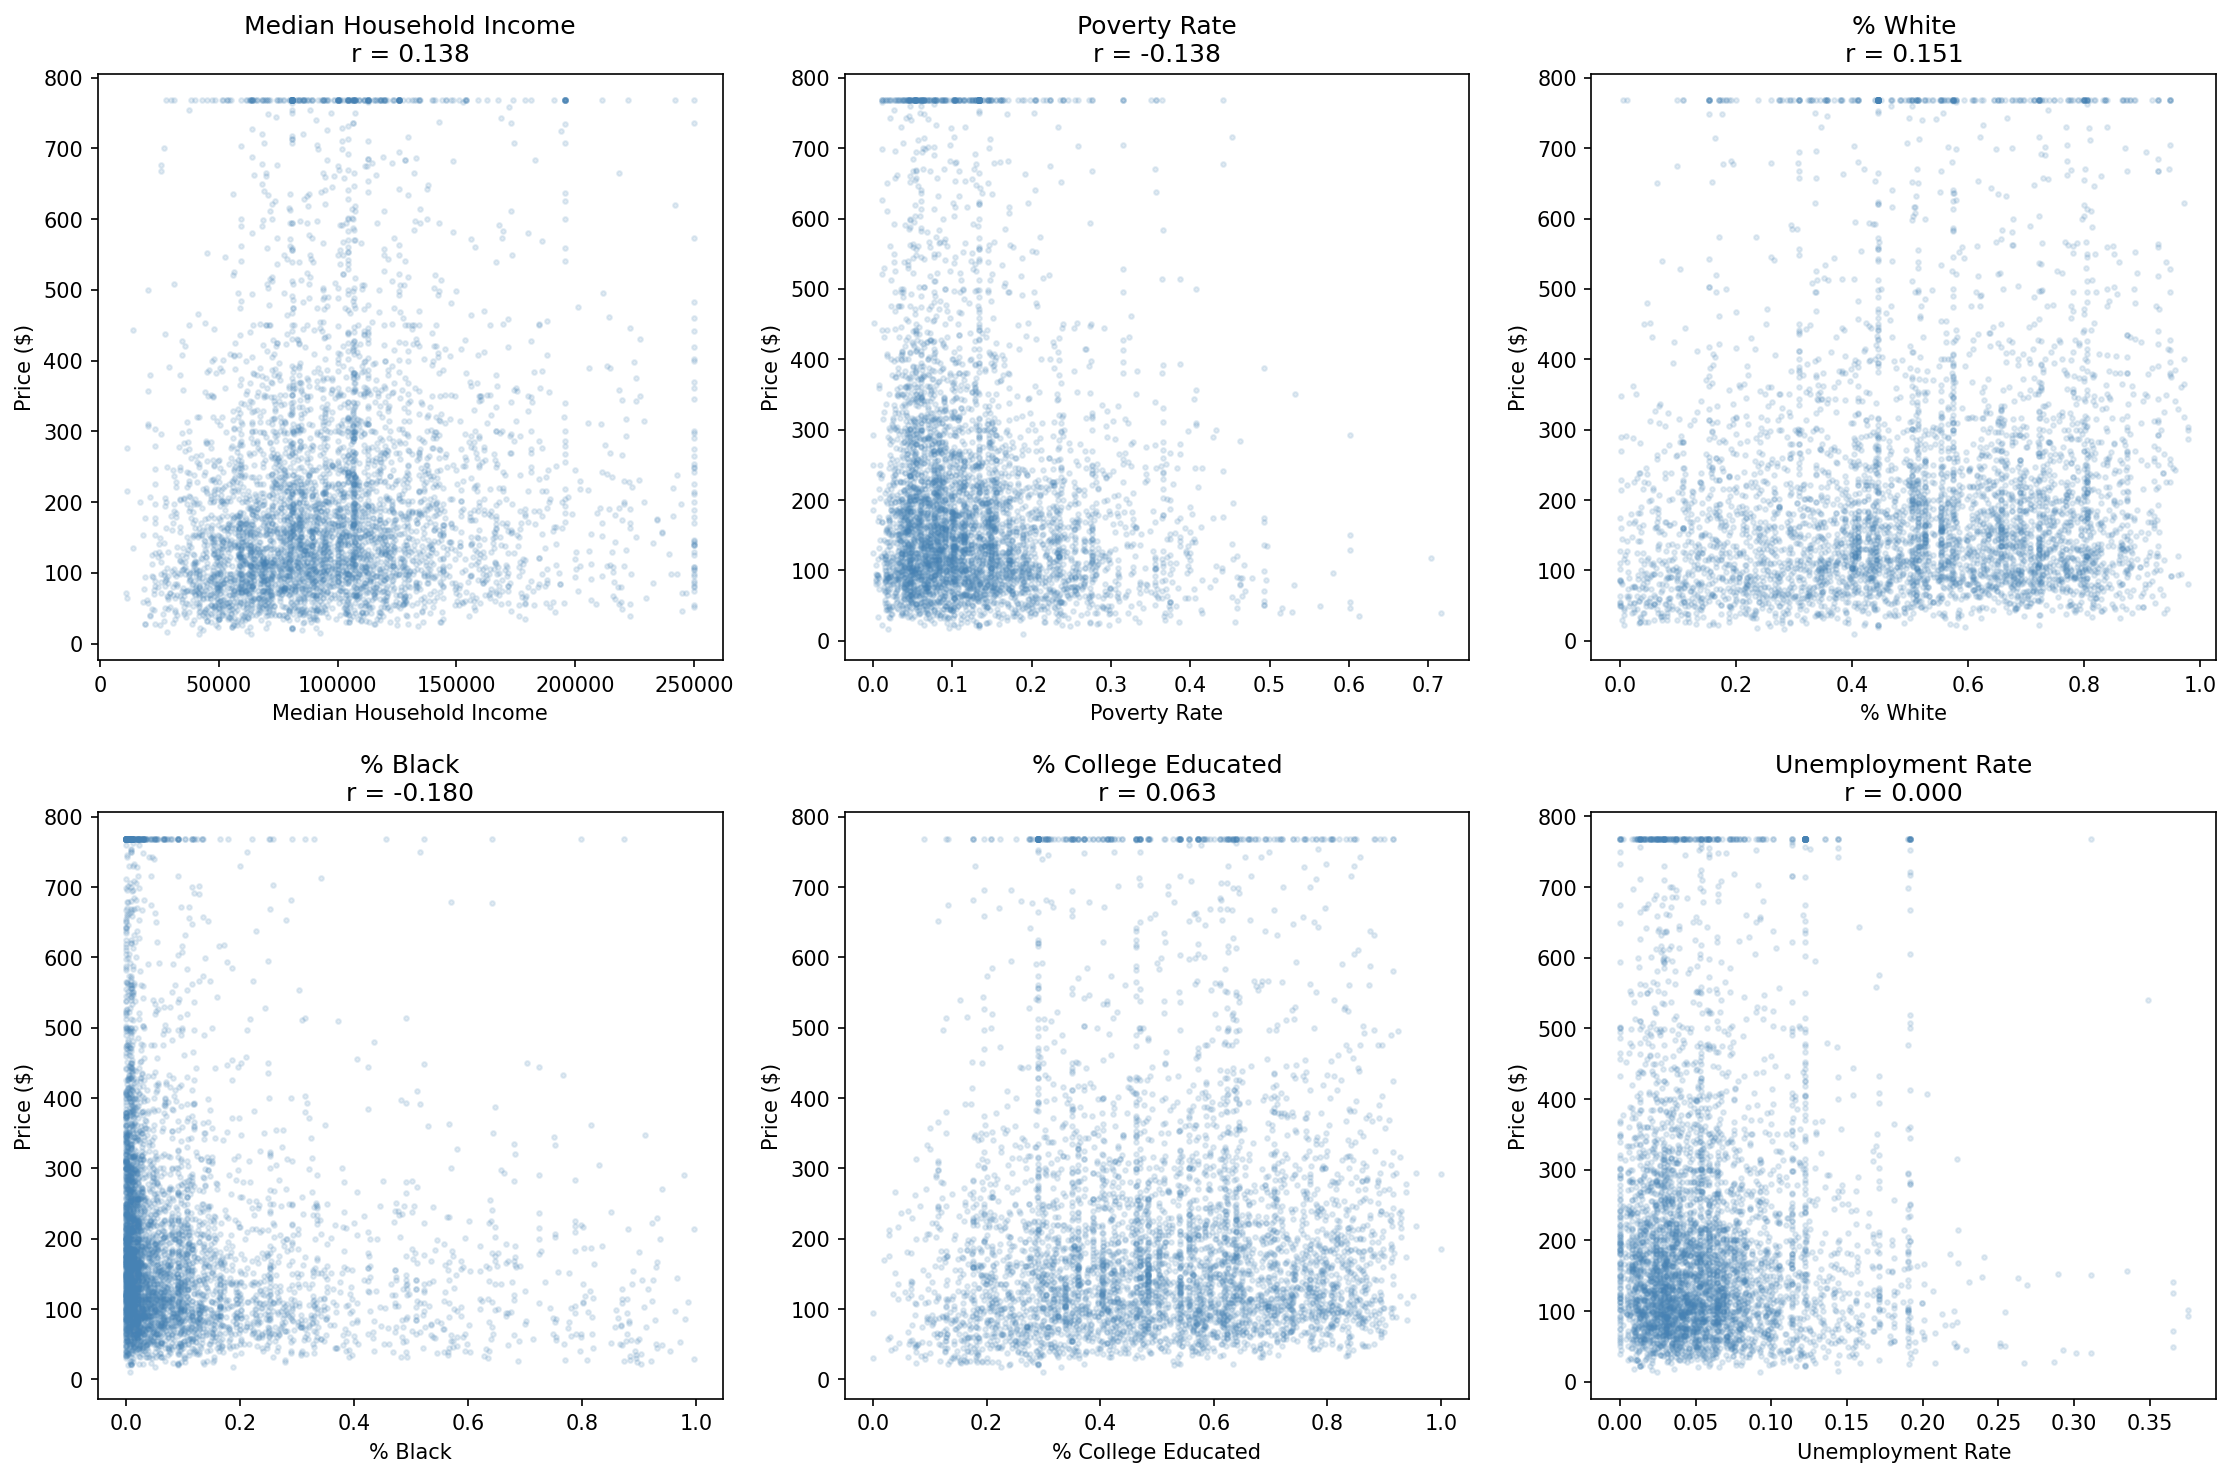

In [ ]:
demo_cols = ["median_household_income", "poverty_rate", "pct_white",
             "pct_black", "pct_college_educated", "unemployment_rate"]
demo_labels = ["Median Household Income", "Poverty Rate", "% White",
               "% Black", "% College Educated", "Unemployment Rate"]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col, label in zip(axes.flatten(), demo_cols, demo_labels):
    sample = df_price.dropna(subset=[col]).sample(min(5000, len(df_price)), random_state=42)
    ax.scatter(sample[col], sample["price"], alpha=0.15, s=5, color="steelblue")
    ax.set_xlabel(label)
    ax.set_ylabel("Price ($)")
    r = df_price[[col, "price"]].dropna().corr().iloc[0, 1]
    ax.set_title(f"{label}\nr = {r:.3f}")

plt.tight_layout()
plt.show()

The scatter plots show that higher median household income and college education are associated with 
higher prices. Poverty rate, pct_black, and unemployment rate are negatively associated with price. 
These relationships are consistent with our hypothesis that neighborhood demographics play a role in listing outcomes.

### Listings by City

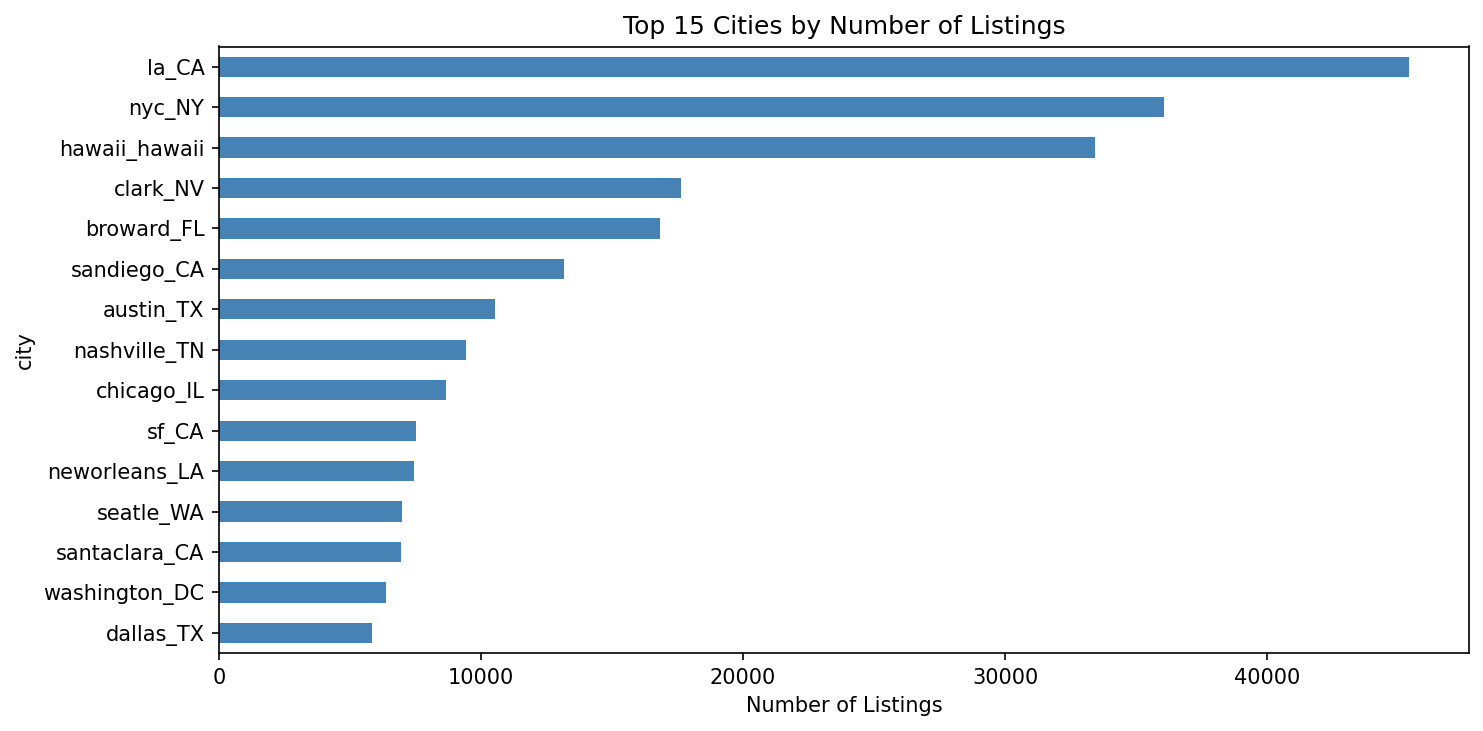

In [ ]:
city_counts = df["city"].value_counts().head(15)
fig, ax = plt.subplots(figsize=(10, 5))
city_counts.plot(kind="barh", color="steelblue", ax=ax)
ax.set_xlabel("Number of Listings")
ax.set_title("Top 15 Cities by Number of Listings")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Modeling

### Feature Preparation

We organize our features into two groups:
- **Listing features**: accommodates, bedrooms, beds, bathrooms, minimum_nights, availability, reviews, host attributes, amenities, room/property type dummies
- **Demographic features**: median_household_income, median_gross_rent, median_home_value, poverty_rate, racial composition, education, unemployment

This separation lets us test how much predictive power the demographic variables add on top of listing attributes.

In [ ]:
listing_features = [
    "accommodates", "bedrooms", "beds", "bathrooms",
    "minimum_nights", "maximum_nights",
    "availability_365", "availability_30",
    "number_of_reviews", "reviews_per_month",
    "review_scores_rating", "review_scores_cleanliness",
    "review_scores_location", "review_scores_value",
    "host_response_time", "host_response_rate", "host_acceptance_rate",
    "calculated_host_listings_count",
    "has_wifi", "has_parking", "has_pool", "has_gym",
    "instant_bookable", "host_is_superhost",
    "host_identity_verified", "host_has_profile_pic"
]

demo_features = [
    "median_household_income", "median_gross_rent", "median_home_value",
    "total_population", "median_age", "poverty_rate",
    "pct_renter_occupied", "pct_white", "pct_black",
    "pct_asian", "pct_hispanic", "pct_college_educated",
    "unemployment_rate"
]

# encode categorical variables
room_dummies = pd.get_dummies(df["room_type"], prefix="room", drop_first=True)
top_props = df["property_type"].value_counts().head(5).index
df["property_type_grouped"] = df["property_type"].where(
    df["property_type"].isin(top_props), "other"
)
prop_dummies = pd.get_dummies(df["property_type_grouped"], prefix="prop", drop_first=True)

all_features = listing_features + demo_features
feature_df = pd.concat([df[all_features], room_dummies, prop_dummies], axis=1)

# convert booleans to int
bool_cols = feature_df.select_dtypes(include=["bool"]).columns
feature_df[bool_cols] = feature_df[bool_cols].astype(int)

print(f"Total features: {feature_df.shape[1]}")

### 4.1 Price Prediction (Regression)

We predict nightly price using log-transformed price as the target to handle the right-skewed distribution. 
We use an 80/20 train-test split.

In [ ]:
# only use rows with valid price
price_mask = df["price"].notna() & (df["price"] > 0)
X_price = feature_df[price_mask].copy()
y_price = np.log1p(df.loc[price_mask, "price"])

# drop rows with missing features
valid_mask = X_price.notna().all(axis=1)
X_price = X_price[valid_mask]
y_price = y_price[valid_mask]
X_price = X_price.fillna(X_price.median())

print(f"Samples for price prediction: {len(X_price):,}")

X_train, X_test, y_train, y_test = train_test_split(
    X_price, y_price, test_size=0.2, random_state=42
)

#### Linear Regression Baseline

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

y_test_actual = np.expm1(y_test)
y_pred_lr_actual = np.expm1(y_pred_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test_actual, y_pred_lr_actual))
mae_lr = mean_absolute_error(y_test_actual, y_pred_lr_actual)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression Results:")
print(f"R²: {r2_lr:.4f}")
print(f"RMSE: ${rmse_lr:.2f}")
print(f"MAE: ${mae_lr:.2f}")

#### Random Forest

In [ ]:
rf_reg = RandomForestRegressor(n_estimators=200, max_depth=15, min_samples_leaf=10, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_test)

y_pred_rf_actual = np.expm1(y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_actual, y_pred_rf_actual))
mae_rf = mean_absolute_error(y_test_actual, y_pred_rf_actual)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Results:")
print(f"R²: {r2_rf:.4f}")
print(f"RMSE: ${rmse_rf:.2f}")
print(f"MAE: ${mae_rf:.2f}")

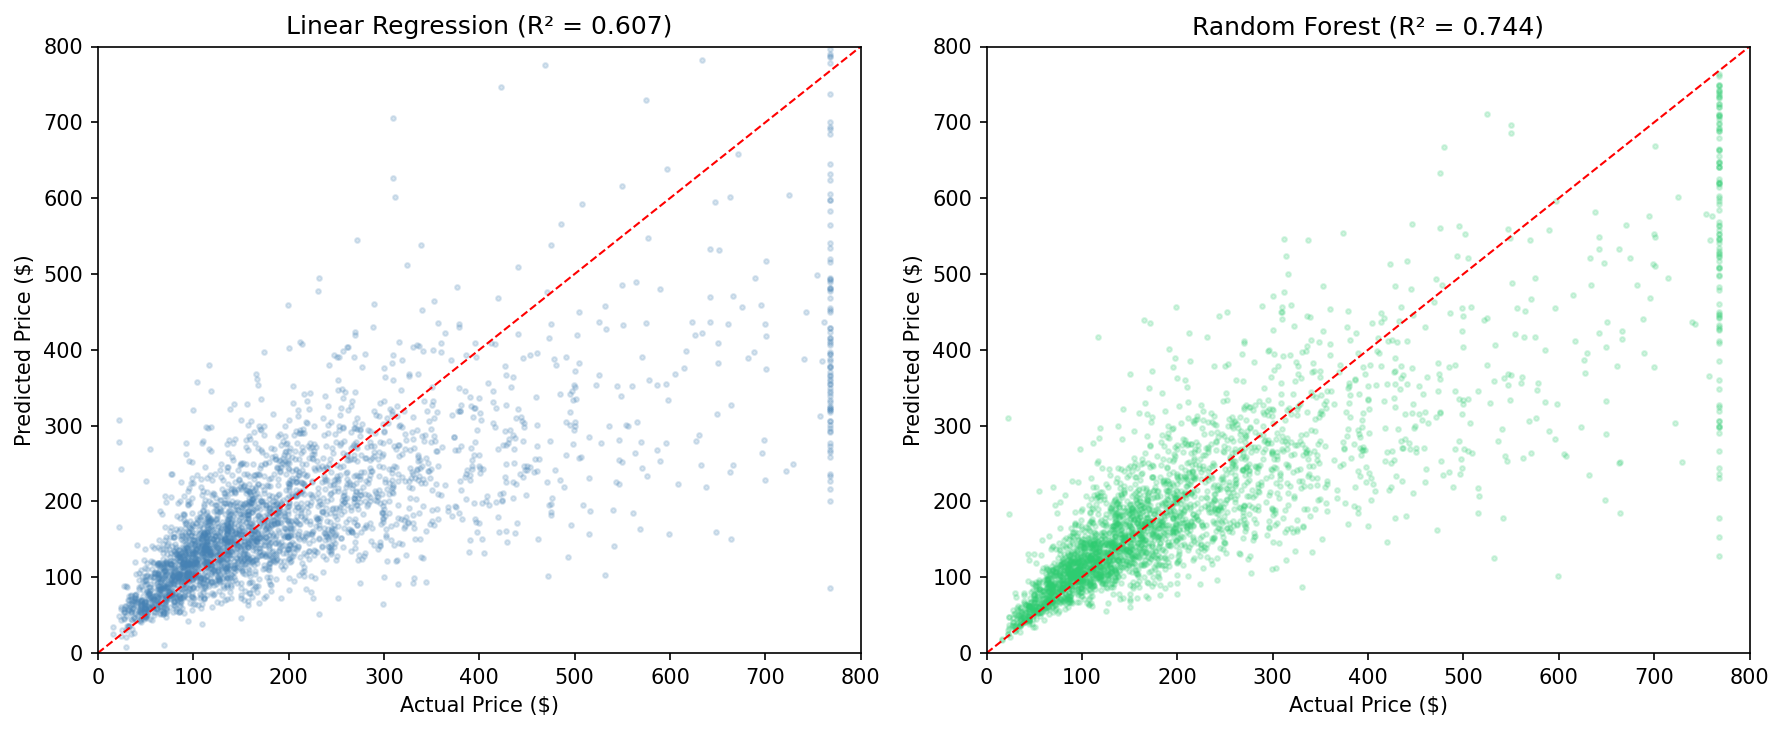

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sample_idx = np.random.RandomState(42).choice(len(y_test_actual), size=3000, replace=False)

axes[0].scatter(y_test_actual.values[sample_idx], y_pred_lr_actual[sample_idx],
                alpha=0.2, s=5, color="steelblue")
axes[0].plot([0, 800], [0, 800], "r--", linewidth=1)
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_title(f"Linear Regression (R² = {r2_lr:.3f})")
axes[0].set_xlim(0, 800)
axes[0].set_ylim(0, 800)

axes[1].scatter(y_test_actual.values[sample_idx], y_pred_rf_actual[sample_idx],
                alpha=0.2, s=5, color="#2ECC71")
axes[1].plot([0, 800], [0, 800], "r--", linewidth=1)
axes[1].set_xlabel("Actual Price ($)")
axes[1].set_ylabel("Predicted Price ($)")
axes[1].set_title(f"Random Forest (R² = {r2_rf:.3f})")
axes[1].set_xlim(0, 800)
axes[1].set_ylim(0, 800)

plt.tight_layout()
plt.show()

### 4.2 Occupancy Classification

We define high occupancy as listings above the median occupancy (30 nights/year) and frame this as a binary classification problem.

In [ ]:
median_occ = df["estimated_occupancy_l365d"].median()
df["high_occupancy"] = (df["estimated_occupancy_l365d"] > median_occ).astype(int)

X_occ = feature_df.copy()
y_occ = df["high_occupancy"]

valid_mask_occ = X_occ.notna().all(axis=1) & y_occ.notna()
X_occ = X_occ[valid_mask_occ]
y_occ = y_occ[valid_mask_occ]
X_occ = X_occ.fillna(X_occ.median())

print(f"Samples for occupancy classification: {len(X_occ):,}")
print(f"Median occupancy threshold: {median_occ} nights")
print(f"High occupancy rate: {y_occ.mean()*100:.1f}%")

In [ ]:
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_occ, y_occ, test_size=0.2, random_state=42, stratify=y_occ
)

scaler_o = StandardScaler()
X_train_o_scaled = scaler_o.fit_transform(X_train_o)
X_test_o_scaled = scaler_o.transform(X_test_o)

# logistic regression baseline
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_o_scaled, y_train_o)
y_pred_log = log_reg.predict(X_test_o_scaled)
y_prob_log = log_reg.predict_proba(X_test_o_scaled)[:, 1]

print("Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test_o, y_pred_log):.4f}")
print(f"AUC: {roc_auc_score(y_test_o, y_prob_log):.4f}")
print(classification_report(y_test_o, y_pred_log, target_names=["Low", "High"]))

In [ ]:
# random forest classifier
rf_clf = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=10,
    random_state=42, n_jobs=-1
)
rf_clf.fit(X_train_o, y_train_o)
y_pred_rf_clf = rf_clf.predict(X_test_o)
y_prob_rf_clf = rf_clf.predict_proba(X_test_o)[:, 1]

print("Random Forest Classifier:")
print(f"Accuracy: {accuracy_score(y_test_o, y_pred_rf_clf):.4f}")
print(f"AUC: {roc_auc_score(y_test_o, y_prob_rf_clf):.4f}")
print(classification_report(y_test_o, y_pred_rf_clf, target_names=["Low", "High"]))

### 4.3 Feature Importance

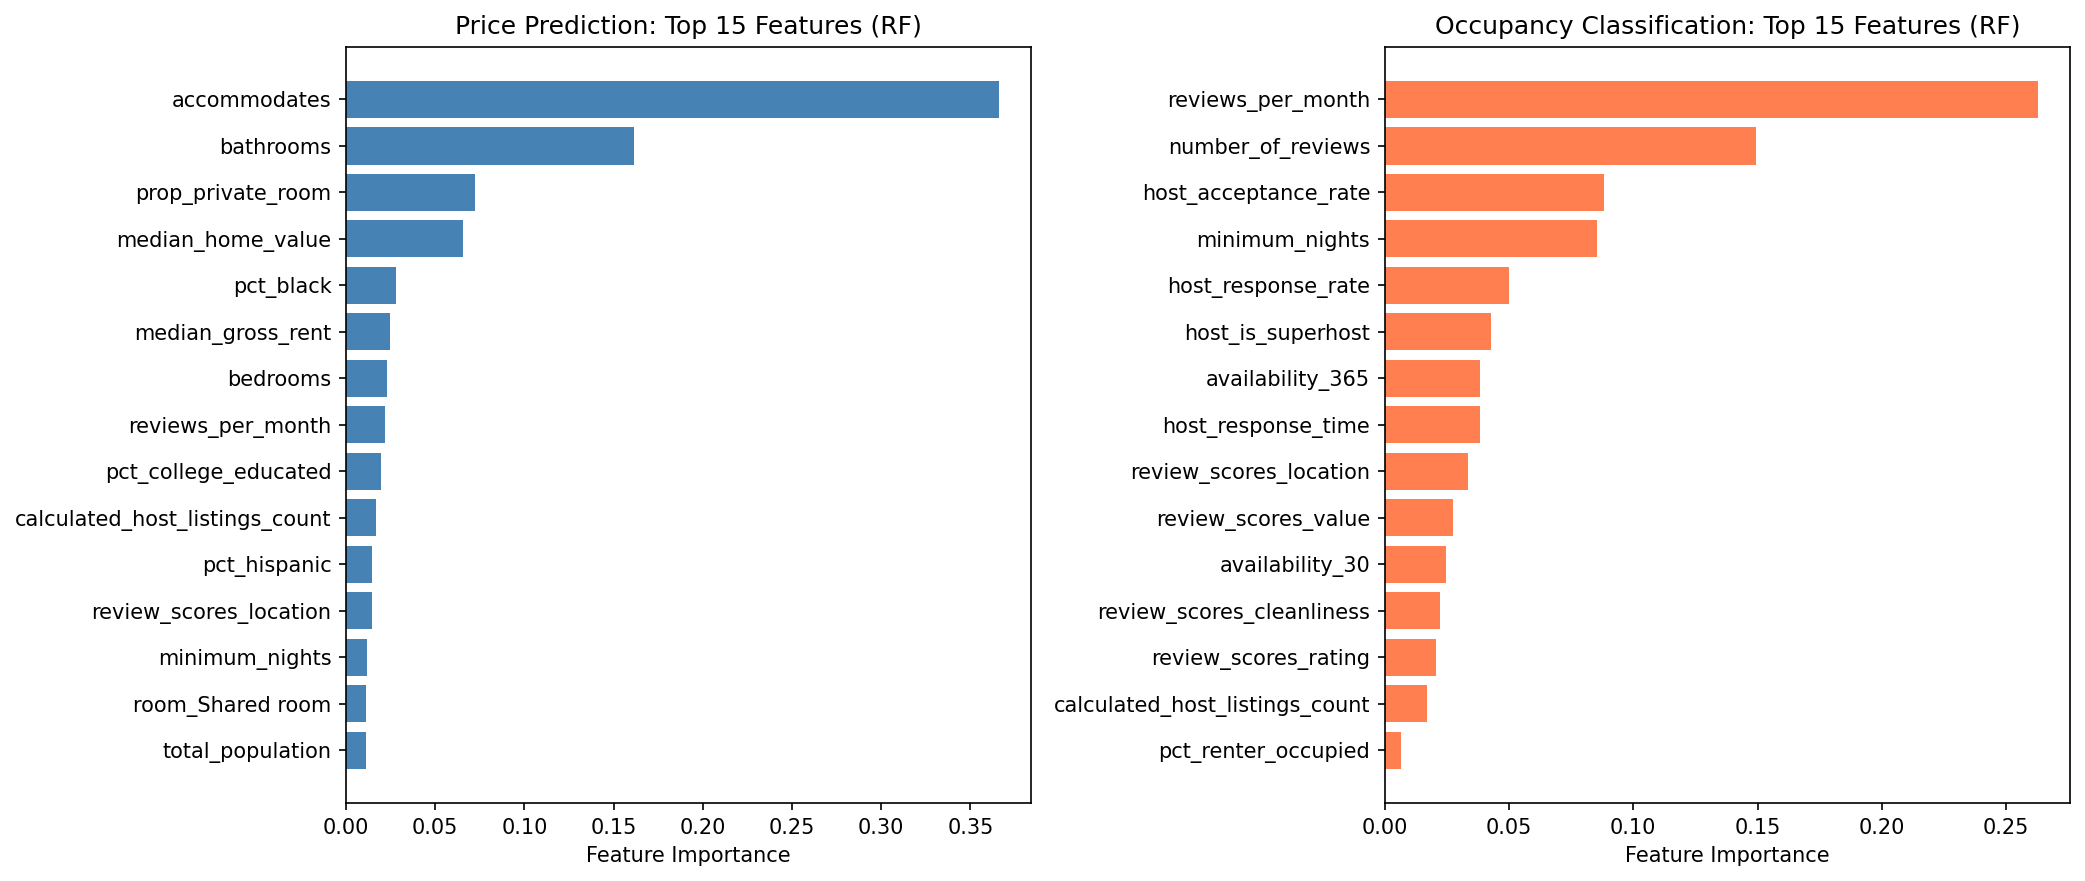

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# price
imp_price = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_reg.feature_importances_
}).sort_values("importance", ascending=False).head(15)

axes[0].barh(range(len(imp_price)), imp_price["importance"].values, color="steelblue")
axes[0].set_yticks(range(len(imp_price)))
axes[0].set_yticklabels(imp_price["feature"].values)
axes[0].invert_yaxis()
axes[0].set_xlabel("Feature Importance")
axes[0].set_title("Price Prediction: Top 15 Features (RF)")

# occupancy
imp_occ = pd.DataFrame({
    "feature": X_train_o.columns,
    "importance": rf_clf.feature_importances_
}).sort_values("importance", ascending=False).head(15)

axes[1].barh(range(len(imp_occ)), imp_occ["importance"].values, color="coral")
axes[1].set_yticks(range(len(imp_occ)))
axes[1].set_yticklabels(imp_occ["feature"].values)
axes[1].invert_yaxis()
axes[1].set_xlabel("Feature Importance")
axes[1].set_title("Occupancy Classification: Top 15 Features (RF)")

plt.tight_layout()
plt.show()

For price prediction, the most important features are listing attributes like accommodates, bathrooms, 
and property type. But demographic features also appear in the top 15, especially median_home_value 
(4th), pct_black (5th), and median_gross_rent (6th), which suggests neighborhood demographics do 
contribute meaningfully to predicting price.

For occupancy, the top features are almost entirely listing and host attributes (reviews_per_month, 
number_of_reviews, host_acceptance_rate). Demographics play a smaller role here.

### 4.4 Impact of Demographic Features

To directly test our research question about whether demographics predict listing outcomes, we compare 
Random Forest models trained with vs. without demographic features.

In [ ]:
listing_only_cols = [c for c in X_train.columns if c not in demo_features]

# price ablation
rf_listing = RandomForestRegressor(
    n_estimators=200, max_depth=15, min_samples_leaf=10,
    random_state=42, n_jobs=-1
)
rf_listing.fit(X_train[listing_only_cols], y_train)
y_pred_listing = rf_listing.predict(X_test[listing_only_cols])
r2_listing = r2_score(y_test, y_pred_listing)

print("PRICE PREDICTION:")
print(f"Listing features only:  R² = {r2_listing:.4f}")
print(f"Listing + Demographics: R² = {r2_rf:.4f}")
print(f"Improvement: change R² = {r2_rf - r2_listing:.4f}")

# occupancy ablation
listing_only_cols_o = [c for c in X_train_o.columns if c not in demo_features]
rf_clf_listing = RandomForestClassifier(
    n_estimators=200, max_depth=15, min_samples_leaf=10,
    random_state=42, n_jobs=-1
)
rf_clf_listing.fit(X_train_o[listing_only_cols_o], y_train_o)
y_prob_listing_o = rf_clf_listing.predict_proba(X_test_o[listing_only_cols_o])[:, 1]
auc_listing = roc_auc_score(y_test_o, y_prob_listing_o)
auc_rf = roc_auc_score(y_test_o, y_prob_rf_clf)

print("\nOCCUPANCY CLASSIFICATION:")
print(f"Listing features only:  AUC = {auc_listing:.4f}")
print(f"Listing + Demographics: AUC = {auc_rf:.4f}")
print(f"Improvement: ΔAUC = {auc_rf - auc_listing:.4f}")

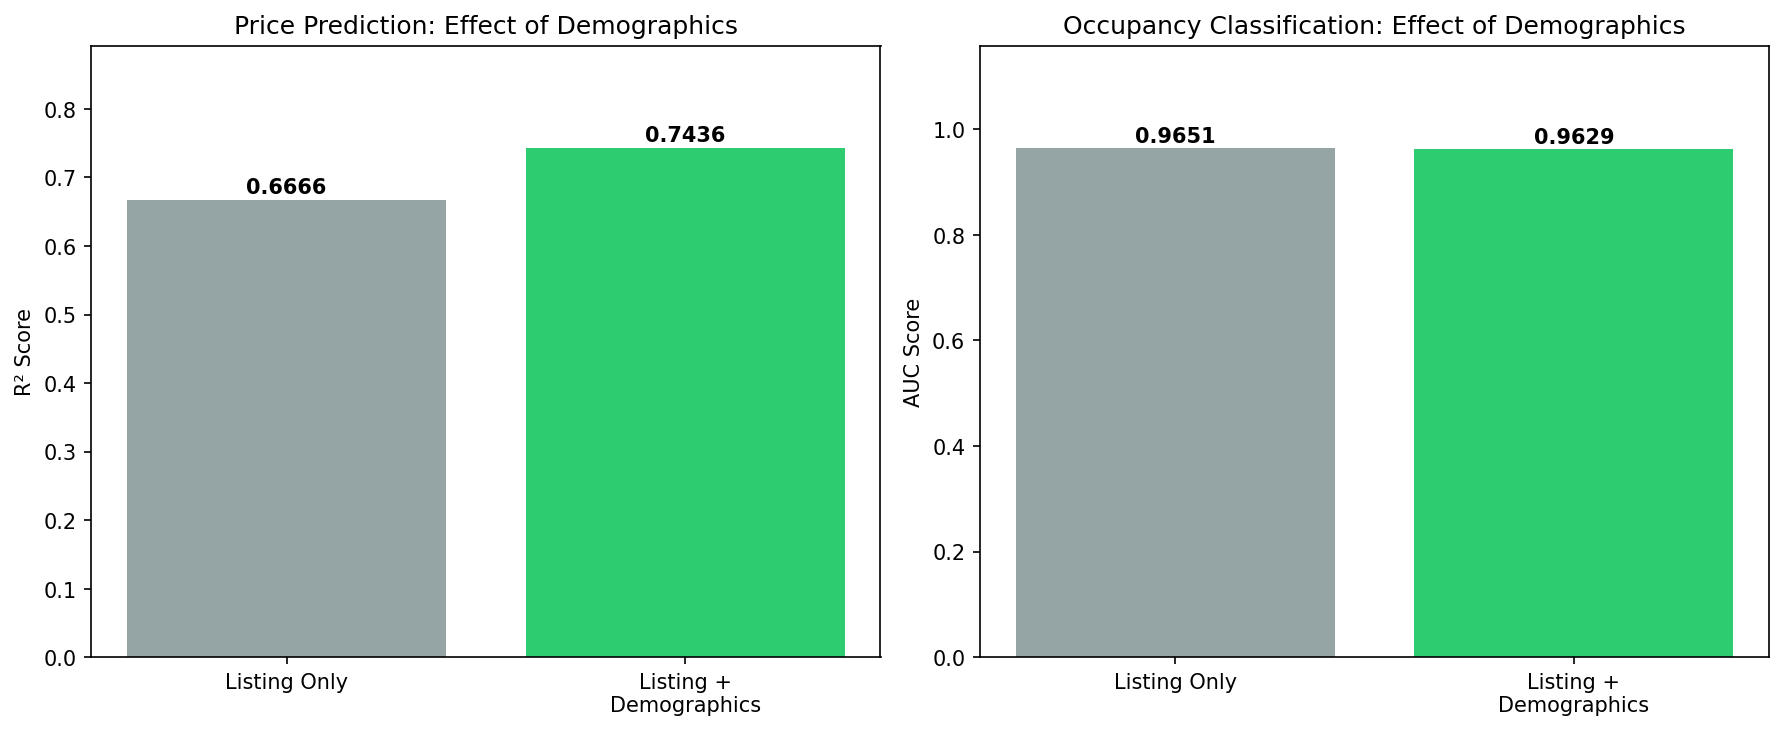

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ["Listing Only", "Listing +\nDemographics"]
r2_ablation = [r2_listing, r2_rf]
colors = ["#95a5a6", "#2ECC71"]

bars = axes[0].bar(labels, r2_ablation, color=colors)
axes[0].set_ylabel("R² Score")
axes[0].set_title("Price Prediction: Effect of Demographics")
axes[0].set_ylim(0, max(r2_ablation) * 1.2)
for bar, v in zip(bars, r2_ablation):
    axes[0].text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.4f}",
                ha="center", fontweight="bold")

auc_ablation = [auc_listing, auc_rf]
bars = axes[1].bar(labels, auc_ablation, color=colors)
axes[1].set_ylabel("AUC Score")
axes[1].set_title("Occupancy Classification: Effect of Demographics")
axes[1].set_ylim(0, max(auc_ablation) * 1.2)
for bar, v in zip(bars, auc_ablation):
    axes[1].text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.4f}",
                ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

The results show a clear asymmetry:
- **Price**: Adding demographics improves R² by 0.077 (from 0.667 to 0.744), a meaningful gain. This suggests that neighborhood-level factors like home values, racial composition, and education levels are genuinely predictive of listing price, even after accounting for listing attributes.
- **Occupancy**: Demographics provide no improvement (ΔAUC ≈ 0). This indicates that occupancy is primarily driven by listing and host quality signals (reviews, response rate, superhost status), not by the neighborhood the listing sits in.

This is an interesting finding. It suggests that the marketplace may embed demographic signals into pricing but not into booking volume, which could have implications for how platform algorithms interact with neighborhood characteristics.

## 5. Summary of Results

| Task | Model | Metric | Score |
|------|-------|--------|-------|
| Price Prediction | Linear Regression | R² | 0.607 |
| Price Prediction | Random Forest | R² | 0.744 |
| Occupancy Classification | Logistic Regression | AUC | 0.893 |
| Occupancy Classification | Random Forest | AUC | 0.963 |
